<a href="https://colab.research.google.com/github/Shuvo1523004/Machine-Learning/blob/main/TRB_3DPC_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRB 3D-Printed Concrete Machine-Learning Analysis

This Google Colab notebook reproduces the **final revised TRB analysis**:

- 299 raw enriched records → 267 valid nonzero compressive-strength specimens
- 267 specimens grouped into 95 unique complete mixture combinations
- Six-model benchmark using mixture-level `GroupKFold`
- Simplified 14-input screening model using 95 mixture medians
- Normalized compressive-strength random-fold versus source-paper-grouped validation
- Descriptive statistics, model tables, SHAP analysis, and journal figures
- Final Random Forest screening model and Gradio interface

### Files required

Upload these two files when prompted:

1. `1-s2.0-S2214509524010866-mmc1.csv`
2. `dataset.xlsx`

The final user-facing model excludes **loading direction** and **fiber type**, and it does **not** report 90% or 95% prediction intervals.


In [1]:
# Install packages required by the analysis.
# Run this cell once at the beginning of the Colab session.

!pip -q install "xgboost==3.1.3" "shap==0.50.0" "gradio==6.5.1" "openpyxl>=3.1.5"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
python-fasthtml 0.14.6 requires starlette>=1.0.1, but you have starlette 0.52.1 which is incompatible.
google-adk 2.4.0 requires starlette<2,>=1.0.1, but you have starlette 0.52.1 which is incompatible.


In [2]:
# Imports and global settings

from __future__ import annotations

import json
import math
import os
import shutil
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.stats import gaussian_kde
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROOT = Path("/content/3dpc_trb_analysis")
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

for directory in [DATA_DIR, RESULTS_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "savefig.facecolor": "white",
})

print("Working directory:", ROOT)


Working directory: /content/3dpc_trb_analysis


## 1. Upload the original data files

Select both required files in the upload dialog. When running outside Colab, place them in the current working directory and adjust the paths manually.


In [5]:
# Upload the two original source files.

try:
    from google.colab import files

    uploaded = files.upload()
    for filename, content in uploaded.items():
        output_path = DATA_DIR / Path(filename).name
        output_path.write_bytes(content)
        print("Saved:", output_path)
except ImportError:
    print("Not running in Google Colab.")
    print("Copy the required files into:", DATA_DIR)

RAW_ENRICHED_PATH = DATA_DIR / "1-s2.0-S2214509524010866-mmc1.csv"
NORMALIZED_WORKBOOK_PATH = DATA_DIR / "datasets.xlsx"

required = [RAW_ENRICHED_PATH, NORMALIZED_WORKBOOK_PATH]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files:\n" + "\n".join(missing)
    )

print("Both source files are available.")


Saving datasets.xlsx to datasets.xlsx
Saving 1-s2.0-S2214509524010866-mmc1.csv to 1-s2.0-S2214509524010866-mmc1.csv
Saved: /content/3dpc_trb_analysis/data/datasets.xlsx
Saved: /content/3dpc_trb_analysis/data/1-s2.0-S2214509524010866-mmc1.csv
Both source files are available.


## 2. Harmonize and clean the datasets

The enriched CSV contains 299 rows. Thirty-two rows have a target compressive strength coded as zero. These are treated as unavailable target measurements and removed. The remaining 267 specimens represent 95 complete input combinations.

The normalized workbook is read from the `CS` worksheet and retains its source-paper identifier for transferability testing.


In [6]:
# Prepare the final 267-specimen and 95-mixture datasets.

raw = pd.read_csv(RAW_ENRICHED_PATH).drop(columns=["Unnamed: 17"], errors="ignore")

source_to_final = {
    "OPC  (kg/m3)": "OPC_kg_m3",
    "S (kg/m3)": "Sand_kg_m3",
    "W/B": "Water_Binder_Ratio",
    "FA (kg/m3)": "Fly_Ash_kg_m3",
    "GS (kg/m3)": "GGBS_or_GS_kg_m3",
    "SF (kg/m3)": "Silica_Fume_kg_m3",
    "SP (kg/m3)": "Superplasticizer_kg_m3",
    "HPMC (kg/m3)": "HPMC_kg_m3",
    "W (kg/m3)": "Water_kg_m3",
    "Vf (%)": "Fiber_Volume_source_scale",
    "CA (days)": "Curing_Age_days",
    "LD (x,y,z)": "Loading_Direction_code",
    "Lf/Df": "Fiber_Aspect_Ratio",
    "Df (mm)": "Fiber_Diameter_source_um",
    "Lf (mm)": "Fiber_Length_mm",
    "Ftype": "Fiber_Type_code",
    "CS (MPa)": "CS_MPa",
}

all_required_source_columns = list(source_to_final)
missing_columns = sorted(set(all_required_source_columns) - set(raw.columns))
if missing_columns:
    raise ValueError(f"Missing source columns: {missing_columns}")

rich = raw[all_required_source_columns].rename(columns=source_to_final).copy()
for column in rich.columns:
    rich[column] = pd.to_numeric(rich[column], errors="coerce")

SPECIMEN_FEATURES = [
    "OPC_kg_m3",
    "Sand_kg_m3",
    "Water_Binder_Ratio",
    "Fly_Ash_kg_m3",
    "GGBS_or_GS_kg_m3",
    "Silica_Fume_kg_m3",
    "Superplasticizer_kg_m3",
    "HPMC_kg_m3",
    "Water_kg_m3",
    "Fiber_Volume_source_scale",
    "Curing_Age_days",
    "Loading_Direction_code",
    "Fiber_Aspect_Ratio",
    "Fiber_Diameter_source_um",
    "Fiber_Length_mm",
    "Fiber_Type_code",
]
CATEGORICAL_FEATURES = ["Loading_Direction_code", "Fiber_Type_code"]
NUMERIC_FEATURES = [
    feature for feature in SPECIMEN_FEATURES
    if feature not in CATEGORICAL_FEATURES
]

original_rows = len(rich)
zero_target_rows = int((rich["CS_MPa"] <= 0).sum())

specimen_data = rich.loc[rich["CS_MPa"] > 0].copy()
specimen_data["Full_Input_Group_ID"] = (
    pd.util.hash_pandas_object(
        specimen_data[SPECIMEN_FEATURES], index=False
    ).astype(str)
)

aggregation = {
    **{feature: (feature, "first") for feature in SPECIMEN_FEATURES},
    "CS_MPa": ("CS_MPa", "median"),
    "Replicate_Count": ("CS_MPa", "size"),
    "CS_MPa_mean": ("CS_MPa", "mean"),
    "CS_MPa_sd": ("CS_MPa", "std"),
}
mixture_data = (
    specimen_data
    .groupby("Full_Input_Group_ID", as_index=False)
    .agg(**aggregation)
)

specimen_path = DATA_DIR / "rich_clean_267_nonzero.csv"
mixture_path = DATA_DIR / "rich_clean_95_mixture_medians.csv"
specimen_data.to_csv(specimen_path, index=False)
mixture_data.to_csv(mixture_path, index=False)

print({
    "raw_rows": original_rows,
    "zero_target_rows_removed": zero_target_rows,
    "final_specimen_rows": len(specimen_data),
    "unique_complete_mixtures": specimen_data["Full_Input_Group_ID"].nunique(),
    "mixture_median_rows": len(mixture_data),
})
print("\nSpecimen columns:")
print(specimen_data.columns.tolist())


{'raw_rows': 299, 'zero_target_rows_removed': 32, 'final_specimen_rows': 267, 'unique_complete_mixtures': 95, 'mixture_median_rows': 95}

Specimen columns:
['OPC_kg_m3', 'Sand_kg_m3', 'Water_Binder_Ratio', 'Fly_Ash_kg_m3', 'GGBS_or_GS_kg_m3', 'Silica_Fume_kg_m3', 'Superplasticizer_kg_m3', 'HPMC_kg_m3', 'Water_kg_m3', 'Fiber_Volume_source_scale', 'Curing_Age_days', 'Loading_Direction_code', 'Fiber_Aspect_Ratio', 'Fiber_Diameter_source_um', 'Fiber_Length_mm', 'Fiber_Type_code', 'CS_MPa', 'Full_Input_Group_ID']


In [7]:
# Prepare the normalized compressive-strength dataset.

normalized = pd.read_excel(NORMALIZED_WORKBOOK_PATH, sheet_name="CS")
normalized["Data source papers"] = normalized["Data source papers"].ffill()
normalized = normalized[
    normalized["Group"].astype(str).str.lower() != "unit"
].copy()

NORMALIZED_FEATURES = [
    "f(OPC)",
    "n(OPC)",
    "f(SAC)",
    "n(SAC)",
    "n(FA)",
    "n(GGBS)",
    "n(SF)",
    "n(W/B)",
    "n(B/S)",
    "n(WRA)",
    "n(Fb-E)",
    "n(Fb-L)",
    "n(Fb)",
]

for column in NORMALIZED_FEATURES + ["CS"]:
    normalized[column] = pd.to_numeric(normalized[column], errors="coerce")

normalized = normalized.rename(
    columns={
        "Data source papers": "Source_Paper",
        "CS": "CS_MPa",
    }
)
normalized = normalized[
    ["Source_Paper", "Group"] + NORMALIZED_FEATURES + ["CS_MPa"]
].dropna(subset=NORMALIZED_FEATURES + ["CS_MPa"])

normalized_path = DATA_DIR / "normalized_cs_254.csv"
normalized.to_csv(normalized_path, index=False)

print({
    "normalized_rows": len(normalized),
    "source_papers": normalized["Source_Paper"].nunique(),
    "predictors": len(NORMALIZED_FEATURES),
})


{'normalized_rows': 254, 'source_papers': 23, 'predictors': 13}


## 3. Reusable evaluation functions


In [8]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
    }


def cross_validated_predictions(estimator, X, y, splits):
    prediction = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (train_index, test_index) in enumerate(splits, start=1):
        fitted = clone(estimator)
        fitted.fit(X.iloc[train_index], y[train_index])
        fold_prediction = np.asarray(
            fitted.predict(X.iloc[test_index]), dtype=float
        )
        prediction[test_index] = fold_prediction

        fold_rows.append({
            "Fold": fold,
            "N_train": len(train_index),
            "N_test": len(test_index),
            **regression_metrics(y[test_index], fold_prediction),
        })

    return pd.DataFrame(fold_rows), prediction


def summarize_model(dataset, model_name, validation, y, prediction, folds):
    pooled = regression_metrics(y, prediction)
    return {
        "Dataset": dataset,
        "Model": model_name,
        "Validation": validation,
        "Pooled_R2": pooled["R2"],
        "Pooled_MAE_MPa": pooled["MAE"],
        "Pooled_RMSE_MPa": pooled["RMSE"],
        "Fold_R2_mean": folds["R2"].mean(),
        "Fold_R2_SD": folds["R2"].std(ddof=1),
        "Fold_MAE_mean_MPa": folds["MAE"].mean(),
        "Fold_MAE_SD_MPa": folds["MAE"].std(ddof=1),
        "Fold_RMSE_mean_MPa": folds["RMSE"].mean(),
        "Fold_RMSE_SD_MPa": folds["RMSE"].std(ddof=1),
    }


def make_one_hot_encoder():
    # Compatible with both newer and older scikit-learn releases.
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=600, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.tiff", dpi=600, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.svg", bbox_inches="tight")
    plt.show()
    plt.close(fig)


## 4. Define all regression models and hyperparameters


In [9]:
# Specimen-level preprocessing and candidate models.

specimen_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        "categorical",
        make_one_hot_encoder(),
        CATEGORICAL_FEATURES,
    ),
])

specimen_models = {
    "Ridge": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]),
    "RBF-SVR": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", SVR(
            kernel="rbf",
            C=695.1928,
            gamma=0.0263665,
            epsilon=0.5,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=800,
            max_depth=18,
            max_features=1.0,
            min_samples_split=8,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Extra Trees": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=800,
            max_depth=18,
            max_features=1.0,
            min_samples_split=8,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", XGBRegressor(
            n_estimators=800,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=1.0,
            min_child_weight=1,
            reg_lambda=3.0,
            reg_alpha=0.01,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "ANN (MLP)": Pipeline([
        ("preprocess", specimen_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=3000,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

# The user-facing screening model excludes loading direction and fiber type.
GUI_FEATURES = [
    feature for feature in SPECIMEN_FEATURES
    if feature not in CATEGORICAL_FEATURES
]

gui_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

gui_models = {
    "Ridge": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", Ridge(alpha=10.0)),
    ]),
    "RBF-SVR": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", SVR(
            kernel="rbf",
            C=100.0,
            gamma="scale",
            epsilon=0.5,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=800,
            max_features=0.8,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "Extra Trees": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=800,
            max_features=0.5,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", XGBRegressor(
            n_estimators=800,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=1.0,
            reg_lambda=3.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "ANN (MLP)": Pipeline([
        ("preprocess", gui_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(32, 16),
            alpha=0.05,
            max_iter=3000,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print("Specimen predictors:", len(SPECIMEN_FEATURES))
print("GUI predictors:", len(GUI_FEATURES))
print("Excluded from GUI:", CATEGORICAL_FEATURES)


Specimen predictors: 16
GUI predictors: 14
Excluded from GUI: ['Loading_Direction_code', 'Fiber_Type_code']


## 5. Run the 267-specimen grouped benchmark

`GroupKFold` uses the complete mixture identifier. All replicate specimens from one mixture remain in the same fold.


In [10]:
X_specimen = specimen_data[SPECIMEN_FEATURES]
y_specimen = specimen_data["CS_MPa"].to_numpy(float)
group_specimen = specimen_data["Full_Input_Group_ID"].astype(str).to_numpy()

specimen_splits = list(
    GroupKFold(n_splits=5).split(
        X_specimen,
        y_specimen,
        groups=group_specimen,
    )
)

performance_rows = []
fold_metric_tables = []
oof_predictions = {}

for model_name, estimator in specimen_models.items():
    folds, prediction = cross_validated_predictions(
        estimator,
        X_specimen,
        y_specimen,
        specimen_splits,
    )

    performance_rows.append(
        summarize_model(
            dataset="Enriched specimen-level (267; 16 predictors)",
            model_name=model_name,
            validation="Five-fold GroupKFold by complete mixture ID",
            y=y_specimen,
            prediction=prediction,
            folds=folds,
        )
    )

    fold_copy = folds.copy()
    fold_copy.insert(0, "Dataset", "267 specimens")
    fold_copy.insert(1, "Model", model_name)
    fold_metric_tables.append(fold_copy)
    oof_predictions[("specimen", model_name)] = prediction

specimen_performance = pd.DataFrame(performance_rows)
display(
    specimen_performance
    .sort_values("Pooled_RMSE_MPa")
    .reset_index(drop=True)
)

specimen_best = (
    specimen_performance
    .sort_values("Pooled_RMSE_MPa")
    .iloc[0]
)
print("\nSelected specimen model:")
print(specimen_best.to_string())


,Dataset,Model,Validation,Pooled_R2,Pooled_MAE_MPa,Pooled_RMSE_MPa,Fold_R2_mean,Fold_R2_SD,Fold_MAE_mean_MPa,Fold_MAE_SD_MPa,Fold_RMSE_mean_MPa,Fold_RMSE_SD_MPa
0,Enriched specimen-level (267; 16 predictors),XGBoost,Five-fold GroupKFold by complete mixture ID,0.952920,6.582922,8.153054,0.946081,0.028056,6.576639,1.028304,8.065951,1.259775
1,Enriched specimen-level (267; 16 predictors),RBF-SVR,Five-fold GroupKFold by complete mixture ID,0.949218,6.550544,8.467550,0.944760,0.021145,6.543472,1.186997,8.343783,1.555215
2,Enriched specimen-level (267; 16 predictors),Random Forest,Five-fold GroupKFold by complete mixture ID,0.945712,7.001220,8.754960,0.939494,0.029231,6.991640,1.468169,8.609249,1.705794
3,Enriched specimen-level (267; 16 predictors),Extra Trees,Five-fold GroupKFold by complete mixture ID,0.941228,7.401017,9.109327,0.934054,0.033674,7.395292,1.775813,8.957644,1.802695
4,Enriched specimen-level (267; 16 predictors),Ridge,Five-fold GroupKFold by complete mixture ID,0.937349,7.612139,9.405159,0.929846,0.022480,7.608631,0.781343,9.371236,0.830176
5,Enriched specimen-level (267; 16 predictors),ANN (MLP),Five-fold GroupKFold by complete mixture ID,0.913775,8.724894,11.033682,0.900654,0.052684,8.725295,1.707784,10.887937,1.998346



Selected specimen model:
Dataset               Enriched specimen-level (267; 16 predictors)
Model                                                      XGBoost
Validation             Five-fold GroupKFold by complete mixture ID
Pooled_R2                                                  0.95292
Pooled_MAE_MPa                                            6.582922
Pooled_RMSE_MPa                                           8.153054
Fold_R2_mean                                              0.946081
Fold_R2_SD                                                0.028056
Fold_MAE_mean_MPa                                         6.576639
Fold_MAE_SD_MPa                                           1.028304
Fold_RMSE_mean_MPa                                        8.065951
Fold_RMSE_SD_MPa                                          1.259775


## 6. Run the 95-mixture, 14-feature screening benchmark


In [11]:
X_gui = mixture_data[GUI_FEATURES]
y_gui = mixture_data["CS_MPa"].to_numpy(float)

gui_splits = list(
    KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ).split(X_gui)
)

gui_performance_rows = []

for model_name, estimator in gui_models.items():
    folds, prediction = cross_validated_predictions(
        estimator,
        X_gui,
        y_gui,
        gui_splits,
    )

    gui_performance_rows.append(
        summarize_model(
            dataset="Mixture-median GUI (95; 14 predictors)",
            model_name=model_name,
            validation="Shuffled five-fold CV across unique mixtures",
            y=y_gui,
            prediction=prediction,
            folds=folds,
        )
    )

    fold_copy = folds.copy()
    fold_copy.insert(0, "Dataset", "95 mixture medians")
    fold_copy.insert(1, "Model", model_name)
    fold_metric_tables.append(fold_copy)
    oof_predictions[("gui", model_name)] = prediction

gui_performance = pd.DataFrame(gui_performance_rows)
display(
    gui_performance
    .sort_values("Pooled_RMSE_MPa")
    .reset_index(drop=True)
)

gui_best = (
    gui_performance
    .sort_values("Pooled_RMSE_MPa")
    .iloc[0]
)
print("\nSelected screening model:")
print(gui_best.to_string())


,Dataset,Model,Validation,Pooled_R2,Pooled_MAE_MPa,Pooled_RMSE_MPa,Fold_R2_mean,Fold_R2_SD,Fold_MAE_mean_MPa,Fold_MAE_SD_MPa,Fold_RMSE_mean_MPa,Fold_RMSE_SD_MPa
0,Mixture-median GUI (95; 14 predictors),RBF-SVR,Shuffled five-fold CV across unique mixtures,0.917362,7.699667,9.361022,0.902977,0.043120,7.699667,1.512458,9.221395,1.800905
1,Mixture-median GUI (95; 14 predictors),XGBoost,Shuffled five-fold CV across unique mixtures,0.911402,7.523936,9.692713,0.893367,0.066835,7.523936,1.783624,9.464976,2.335307
2,Mixture-median GUI (95; 14 predictors),Ridge,Shuffled five-fold CV across unique mixtures,0.908195,7.989322,9.866611,0.893116,0.051128,7.989322,1.791741,9.665747,2.214538
3,Mixture-median GUI (95; 14 predictors),Random Forest,Shuffled five-fold CV across unique mixtures,0.904472,7.699998,10.064700,0.883697,0.083924,7.699998,1.989433,9.768609,2.709349
4,Mixture-median GUI (95; 14 predictors),Extra Trees,Shuffled five-fold CV across unique mixtures,0.897576,8.007019,10.421624,0.874650,0.090038,8.007019,2.039005,10.150562,2.640159
5,Mixture-median GUI (95; 14 predictors),ANN (MLP),Shuffled five-fold CV across unique mixtures,0.829542,10.795674,13.444457,0.799542,0.106741,10.795674,2.891525,13.056029,3.587048



Selected screening model:
Dataset                     Mixture-median GUI (95; 14 predictors)
Model                                                      RBF-SVR
Validation            Shuffled five-fold CV across unique mixtures
Pooled_R2                                                 0.917362
Pooled_MAE_MPa                                            7.699667
Pooled_RMSE_MPa                                           9.361022
Fold_R2_mean                                              0.902977
Fold_R2_SD                                                 0.04312
Fold_MAE_mean_MPa                                         7.699667
Fold_MAE_SD_MPa                                           1.512458
Fold_RMSE_mean_MPa                                        9.221395
Fold_RMSE_SD_MPa                                          1.800905


## 7. Verify the principal TRB results

Minor differences can occur if a future package version changes an algorithm implementation. The expected final values are printed below.


In [12]:
EXPECTED = {
    "specimen_xgboost": {
        "R2": 0.9529201676,
        "MAE": 6.5829220054,
        "RMSE": 8.1530541293,
    },
    "gui_random_forest_14": {
        "R2": 0.9175218720,
        "MAE": 7.4889025889,
        "RMSE": 9.3519846468,
    },
}

def compare_expected(name, actual_row, tolerance=0.005):
    actual = {
        "R2": float(actual_row["Pooled_R2"]),
        "MAE": float(actual_row["Pooled_MAE_MPa"]),
        "RMSE": float(actual_row["Pooled_RMSE_MPa"]),
    }
    print(f"\n{name}")
    for metric, expected_value in EXPECTED[name].items():
        difference = actual[metric] - expected_value
        status = "OK" if abs(difference) <= tolerance else "CHECK VERSION"
        print(
            f"{metric}: actual={actual[metric]:.6f}, "
            f"expected={expected_value:.6f}, "
            f"difference={difference:+.6f} [{status}]"
        )

xgb_row = specimen_performance[
    specimen_performance["Model"] == "XGBoost"
].iloc[0]
rf_gui_row = gui_performance[
    gui_performance["Model"] == "Random Forest"
].iloc[0]

compare_expected("specimen_xgboost", xgb_row)
compare_expected("gui_random_forest_14", rf_gui_row)



specimen_xgboost
R2: actual=0.952920, expected=0.952920, difference=-0.000000 [OK]
MAE: actual=6.582922, expected=6.582922, difference=-0.000000 [OK]
RMSE: actual=8.153054, expected=8.153054, difference=+0.000000 [OK]

gui_random_forest_14
R2: actual=0.904472, expected=0.917522, difference=-0.013050 [CHECK VERSION]
MAE: actual=7.699998, expected=7.488903, difference=+0.211096 [CHECK VERSION]
RMSE: actual=10.064700, expected=9.351985, difference=+0.712715 [CHECK VERSION]


## 8. Normalized compressive-strength transferability check

This section compares ordinary random folds with source-paper-grouped folds. It intentionally excludes flexural strength.


In [13]:
# Normalized CS candidate models.

normalized_models = {
    "Ridge": Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=10.0)),
    ]),
    "RBF-SVR": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=100.0,
            gamma="scale",
            epsilon=3.0,
        )),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=800,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=800,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=800,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=5.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gaussian Process": Pipeline([
        ("scale", StandardScaler()),
        ("model", GaussianProcessRegressor(
            kernel=(
                ConstantKernel(1.0, (1e-2, 1e2))
                * RBF(
                    np.ones(len(NORMALIZED_FEATURES)),
                    (1e-2, 1e2),
                )
                + WhiteKernel(1.0, (1e-3, 1e2))
            ),
            normalize_y=True,
            n_restarts_optimizer=2,
            random_state=RANDOM_STATE,
            alpha=1e-6,
        )),
    ]),
}

X_normalized = normalized[NORMALIZED_FEATURES].astype(float)
y_normalized = normalized["CS_MPa"].to_numpy(float)
group_normalized = normalized["Source_Paper"].astype(str).to_numpy()

normalized_protocols = {
    "Random 5-fold": list(
        KFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE,
        ).split(X_normalized)
    ),
    "Source-paper grouped 5-fold": list(
        GroupKFold(n_splits=5).split(
            X_normalized,
            y_normalized,
            groups=group_normalized,
        )
    ),
}

normalized_rows = []

for protocol, splits in normalized_protocols.items():
    for model_name, estimator in normalized_models.items():
        folds, prediction = cross_validated_predictions(
            estimator,
            X_normalized,
            y_normalized,
            splits,
        )
        normalized_rows.append(
            summarize_model(
                dataset="Normalized CS 254",
                model_name=model_name,
                validation=protocol,
                y=y_normalized,
                prediction=prediction,
                folds=folds,
            )
        )

normalized_performance = pd.DataFrame(normalized_rows)
display(
    normalized_performance
    .sort_values(["Validation", "Pooled_RMSE_MPa"])
    .reset_index(drop=True)
)

random_best = (
    normalized_performance[
        normalized_performance["Validation"] == "Random 5-fold"
    ]
    .sort_values("Pooled_RMSE_MPa")
    .iloc[0]
)
grouped_best = (
    normalized_performance[
        normalized_performance["Validation"]
        == "Source-paper grouped 5-fold"
    ]
    .sort_values("Pooled_RMSE_MPa")
    .iloc[0]
)

print("\nBest random-fold result:")
print(random_best.to_string())
print("\nBest source-paper-grouped result:")
print(grouped_best.to_string())


,Dataset,Model,Validation,Pooled_R2,Pooled_MAE_MPa,Pooled_RMSE_MPa,Fold_R2_mean,Fold_R2_SD,Fold_MAE_mean_MPa,Fold_MAE_SD_MPa,Fold_RMSE_mean_MPa,Fold_RMSE_SD_MPa
0,Normalized CS 254,Extra Trees,Random 5-fold,0.898799,5.805436,10.020334,0.884845,0.070449,5.814094,1.474908,9.688455,2.922378
1,Normalized CS 254,XGBoost,Random 5-fold,0.891408,6.562122,10.379805,0.879311,0.065205,6.569082,1.318425,10.171457,2.379697
2,Normalized CS 254,Random Forest,Random 5-fold,0.890428,6.143312,10.426536,0.876669,0.076592,6.150818,1.258883,10.139895,2.773906
3,Normalized CS 254,Gaussian Process,Random 5-fold,0.872001,6.676291,11.269244,0.864437,0.052715,6.679539,1.272810,11.068931,2.402948
4,Normalized CS 254,RBF-SVR,Random 5-fold,0.709836,9.477986,16.967297,0.710058,0.105077,9.494814,2.703805,16.496446,4.553832
5,Normalized CS 254,Ridge,Random 5-fold,0.312450,16.946293,26.118190,0.178983,0.887209,16.951783,3.001152,24.664928,9.580643
6,Normalized CS 254,XGBoost,Source-paper grouped 5-fold,0.001577,25.507387,31.473729,-0.894947,0.904842,25.450150,11.738860,29.373345,12.491577
7,Normalized CS 254,RBF-SVR,Source-paper grouped 5-fold,-0.045410,26.037227,32.205810,-1.023606,0.626716,25.988891,8.640520,30.684521,10.755752
8,Normalized CS 254,Random Forest,Source-paper grouped 5-fold,-0.078415,25.650167,32.710249,-1.222189,1.434564,25.602422,12.248858,30.621488,12.726686
9,Normalized CS 254,Ridge,Source-paper grouped 5-fold,-0.117884,27.879754,33.303456,-2.940071,5.296293,27.890446,7.784529,32.605873,7.579641



Best random-fold result:
Dataset               Normalized CS 254
Model                       Extra Trees
Validation                Random 5-fold
Pooled_R2                      0.898799
Pooled_MAE_MPa                 5.805436
Pooled_RMSE_MPa               10.020334
Fold_R2_mean                   0.884845
Fold_R2_SD                     0.070449
Fold_MAE_mean_MPa              5.814094
Fold_MAE_SD_MPa                1.474908
Fold_RMSE_mean_MPa             9.688455
Fold_RMSE_SD_MPa               2.922378

Best source-paper-grouped result:
Dataset                         Normalized CS 254
Model                                     XGBoost
Validation            Source-paper grouped 5-fold
Pooled_R2                                0.001577
Pooled_MAE_MPa                          25.507387
Pooled_RMSE_MPa                         31.473729
Fold_R2_mean                            -0.894947
Fold_R2_SD                               0.904842
Fold_MAE_mean_MPa                        25.45015
Fold_MAE_

## 9. Create final tables


In [14]:
# Consolidated performance and fold-level results.

consolidated_performance = pd.concat(
    [specimen_performance, gui_performance],
    ignore_index=True,
)
fold_level_metrics = pd.concat(
    fold_metric_tables,
    ignore_index=True,
)

consolidated_performance.to_csv(
    TABLE_DIR / "consolidated_model_performance.csv",
    index=False,
)
fold_level_metrics.to_csv(
    TABLE_DIR / "fold_level_metrics.csv",
    index=False,
)

# Out-of-fold predictions used in parity and residual figures.
specimen_xgb_prediction = oof_predictions[("specimen", "XGBoost")]
gui_rf_prediction = oof_predictions[("gui", "Random Forest")]

specimen_oof = pd.DataFrame({
    "Observed_CS_MPa": y_specimen,
    "Predicted_CS_MPa": specimen_xgb_prediction,
    "Residual_MPa": y_specimen - specimen_xgb_prediction,
    "Mixture_ID": group_specimen,
})
gui_oof = pd.DataFrame({
    "Observed_CS_MPa": y_gui,
    "Predicted_CS_MPa": gui_rf_prediction,
    "Residual_MPa": y_gui - gui_rf_prediction,
    "Mixture_ID": mixture_data["Full_Input_Group_ID"].astype(str),
})

specimen_oof.to_csv(
    TABLE_DIR / "specimen_xgboost_oof_predictions.csv",
    index=False,
)
gui_oof.to_csv(
    TABLE_DIR / "gui_random_forest_14feature_oof_predictions.csv",
    index=False,
)

# Descriptive-statistics table.
descriptive_variables = NUMERIC_FEATURES + ["CS_MPa"]
description = specimen_data[descriptive_variables].describe().T

descriptive_statistics = pd.DataFrame({
    "Variable": description.index,
    "N": description["count"].astype(int).values,
    "Mean": description["mean"].values,
    "SD": description["std"].values,
    "Minimum": description["min"].values,
    "Median": description["50%"].values,
    "Maximum": description["max"].values,
    "Zero_percent": [
        float((specimen_data[column] == 0).mean() * 100)
        for column in description.index
    ],
})
descriptive_statistics.to_csv(
    TABLE_DIR / "descriptive_statistics.csv",
    index=False,
)

# Feature dictionary.
definitions = {
    "OPC_kg_m3": ("Ordinary Portland cement content", "kg/m³"),
    "Sand_kg_m3": ("Fine aggregate content", "kg/m³"),
    "Water_Binder_Ratio": ("Water-to-binder ratio", "dimensionless"),
    "Fly_Ash_kg_m3": ("Fly ash content", "kg/m³"),
    "GGBS_or_GS_kg_m3": ("GGBS or slag content", "kg/m³"),
    "Silica_Fume_kg_m3": ("Silica fume content", "kg/m³"),
    "Superplasticizer_kg_m3": ("Superplasticizer content", "kg/m³"),
    "HPMC_kg_m3": ("Hydroxypropyl methylcellulose content", "kg/m³"),
    "Water_kg_m3": ("Mixing-water content", "kg/m³"),
    "Fiber_Volume_source_scale": (
        "Fiber volume value retained on source scale",
        "source scale",
    ),
    "Curing_Age_days": ("Curing age", "days"),
    "Loading_Direction_code": (
        "Coded loading direction",
        "categorical code",
    ),
    "Fiber_Aspect_Ratio": (
        "Fiber length-to-diameter ratio",
        "dimensionless",
    ),
    "Fiber_Diameter_source_um": (
        "Fiber diameter retained on source scale",
        "source-reported scale",
    ),
    "Fiber_Length_mm": ("Fiber length", "mm"),
    "Fiber_Type_code": ("Coded fiber type", "categorical code"),
    "CS_MPa": ("Compressive strength target", "MPa"),
}

feature_dictionary = []
for feature in SPECIMEN_FEATURES + ["CS_MPa"]:
    if feature == "CS_MPa":
        role = "Outcome"
        data_type = "Outcome"
    elif feature in CATEGORICAL_FEATURES:
        role = "Specimen benchmark only"
        data_type = "Categorical"
    else:
        role = "Specimen benchmark and GUI"
        data_type = "Continuous"

    feature_dictionary.append({
        "Name": feature,
        "Description": definitions[feature][0],
        "Units": definitions[feature][1],
        "Data_type": data_type,
        "Role": role,
    })

feature_dictionary = pd.DataFrame(feature_dictionary)
feature_dictionary.to_csv(
    TABLE_DIR / "feature_dictionary.csv",
    index=False,
)

# Normalized transferability summary.
normalized_transferability = pd.DataFrame([
    {
        "Protocol": random_best["Validation"],
        "Selected_model": random_best["Model"],
        "R2": random_best["Pooled_R2"],
        "MAE_MPa": random_best["Pooled_MAE_MPa"],
        "RMSE_MPa": random_best["Pooled_RMSE_MPa"],
    },
    {
        "Protocol": grouped_best["Validation"],
        "Selected_model": grouped_best["Model"],
        "R2": grouped_best["Pooled_R2"],
        "MAE_MPa": grouped_best["Pooled_MAE_MPa"],
        "RMSE_MPa": grouped_best["Pooled_RMSE_MPa"],
    },
])
normalized_transferability.to_csv(
    TABLE_DIR / "normalized_cs_transferability_check.csv",
    index=False,
)

# Export all major tables to one Excel workbook.
excel_path = RESULTS_DIR / "TRB_analysis_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    descriptive_statistics.to_excel(
        writer,
        sheet_name="Descriptive_Statistics",
        index=False,
    )
    consolidated_performance.to_excel(
        writer,
        sheet_name="Model_Performance",
        index=False,
    )
    fold_level_metrics.to_excel(
        writer,
        sheet_name="Fold_Metrics",
        index=False,
    )
    feature_dictionary.to_excel(
        writer,
        sheet_name="Feature_Dictionary",
        index=False,
    )
    normalized_performance.to_excel(
        writer,
        sheet_name="Normalized_CS_All",
        index=False,
    )
    normalized_transferability.to_excel(
        writer,
        sheet_name="Normalized_CS_Check",
        index=False,
    )

print("Saved tables to:", TABLE_DIR)
print("Saved workbook:", excel_path)


Saved tables to: /content/3dpc_trb_analysis/results/tables
Saved workbook: /content/3dpc_trb_analysis/results/TRB_analysis_tables.xlsx


## 10. Figure 1 — study workflow

The cell prints the labels used in the figure.


Figure 1 workflow
Data preparation -> Source data -> Target audit -> Mixture grouping
Model development -> Fold preprocessing -> Model comparison -> SHAP analysis
Deployment -> GUI inputs -> Strength prediction -> Range warning


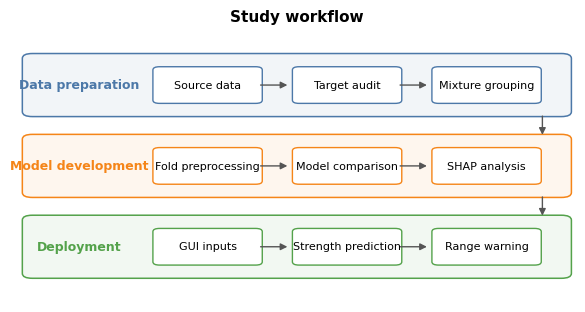

In [15]:
COLORS = {
    "Data preparation": "#4C78A8",
    "Model development": "#F58518",
    "Deployment": "#54A24B",
}

workflow_rows = [
    (
        "Data preparation",
        ["Source data", "Target audit", "Mixture grouping"],
    ),
    (
        "Model development",
        ["Fold preprocessing", "Model comparison", "SHAP analysis"],
    ),
    (
        "Deployment",
        ["GUI inputs", "Strength prediction", "Range warning"],
    ),
]

print("Figure 1 workflow")
for phase, labels in workflow_rows:
    print(phase, "->", " -> ".join(labels))

fig, ax = plt.subplots(figsize=(7.2, 3.5))
ax.set_axis_off()
row_y = [0.70, 0.40, 0.10]

for (phase, labels), y_position in zip(workflow_rows, row_y):
    color = COLORS[phase]

    outer = FancyBboxPatch(
        (0.02, y_position),
        0.96,
        0.21,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=1.1,
        edgecolor=color,
        facecolor=color + "12",
        transform=ax.transAxes,
    )
    ax.add_patch(outer)

    ax.text(
        0.11,
        y_position + 0.105,
        phase,
        ha="center",
        va="center",
        fontsize=9,
        color=color,
        fontweight="bold",
        transform=ax.transAxes,
    )

    x_positions = [0.25, 0.50, 0.75]
    for index, (label, x_position) in enumerate(
        zip(labels, x_positions)
    ):
        box = FancyBboxPatch(
            (x_position, y_position + 0.045),
            0.18,
            0.12,
            boxstyle="round,pad=0.008,rounding_size=0.012",
            linewidth=1.0,
            edgecolor=color,
            facecolor="white",
            transform=ax.transAxes,
        )
        ax.add_patch(box)
        ax.text(
            x_position + 0.09,
            y_position + 0.105,
            label,
            ha="center",
            va="center",
            fontsize=8,
            transform=ax.transAxes,
        )

        if index < 2:
            ax.add_patch(FancyArrowPatch(
                (x_position + 0.18, y_position + 0.105),
                (x_positions[index + 1] - 0.012, y_position + 0.105),
                arrowstyle="-|>",
                mutation_scale=10,
                linewidth=1.0,
                color="#555555",
                transform=ax.transAxes,
            ))

for upper_y, lower_y in zip(row_y[:-1], row_y[1:]):
    ax.add_patch(FancyArrowPatch(
        (0.94, upper_y),
        (0.94, lower_y + 0.21),
        arrowstyle="-|>",
        mutation_scale=10,
        linewidth=1.0,
        color="#555555",
        transform=ax.transAxes,
    ))

ax.set_title("Study workflow", fontsize=11, fontweight="bold", pad=8)
save_figure(fig, "Figure_1_workflow")


## 11. Figure 2 — final strength distributions


Specimen-level data (n = 267)
{'n': 267, 'mean': 67.9485937827341, 'median': 78.0, 'sd': 37.64589996471418, 'minimum': 8.0, 'maximum': 153.4}
Unique mixture medians (n = 95)
{'n': 95, 'mean': 76.58523973626316, 'median': 85.0, 'sd': 32.736501372069114, 'minimum': 9.0, 'maximum': 152.5}


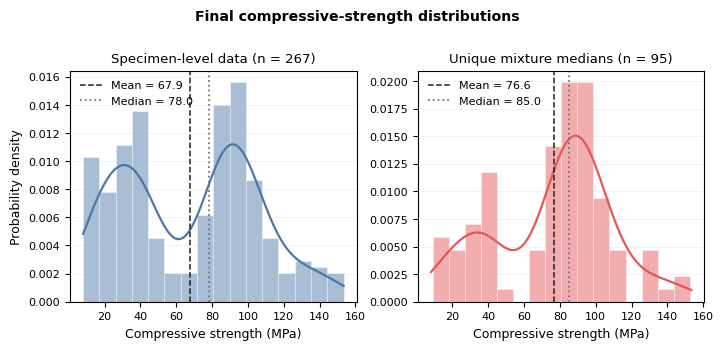

In [16]:
distribution_sets = [
    (
        "Specimen-level data (n = 267)",
        specimen_data["CS_MPa"],
        "#4C78A8",
    ),
    (
        "Unique mixture medians (n = 95)",
        mixture_data["CS_MPa"],
        "#E45756",
    ),
]

for label, series, _ in distribution_sets:
    print(label)
    print({
        "n": len(series),
        "mean": float(series.mean()),
        "median": float(series.median()),
        "sd": float(series.std(ddof=1)),
        "minimum": float(series.min()),
        "maximum": float(series.max()),
    })

x_grid = np.linspace(
    min(
        specimen_data["CS_MPa"].min(),
        mixture_data["CS_MPa"].min(),
    ),
    max(
        specimen_data["CS_MPa"].max(),
        mixture_data["CS_MPa"].max(),
    ),
    300,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.2, 3.4),
    sharex=True,
)

for ax, (label, series, color) in zip(axes, distribution_sets):
    ax.hist(
        series,
        bins=16,
        density=True,
        alpha=0.48,
        color=color,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.plot(
        x_grid,
        gaussian_kde(series)(x_grid),
        color=color,
        linewidth=1.6,
    )
    ax.axvline(
        series.mean(),
        color="#222222",
        linestyle="--",
        linewidth=1.1,
        label=f"Mean = {series.mean():.1f}",
    )
    ax.axvline(
        series.median(),
        color="#777777",
        linestyle=":",
        linewidth=1.3,
        label=f"Median = {series.median():.1f}",
    )
    ax.set_title(label)
    ax.set_xlabel("Compressive strength (MPa)")
    ax.grid(axis="y", alpha=0.2, linewidth=0.5)
    ax.legend(frameon=False, loc="upper left")

axes[0].set_ylabel("Probability density")
fig.suptitle(
    "Final compressive-strength distributions",
    y=1.01,
    fontweight="bold",
)
fig.tight_layout()
save_figure(fig, "Figure_2_strength_distribution")


## 12. Figure 3 — model comparison with fold-level error bars


267 specimens


,Model,Fold_RMSE_mean_MPa,Fold_RMSE_SD_MPa,Pooled_R2,Pooled_MAE_MPa,Pooled_RMSE_MPa
0,XGBoost,8.065951,1.259775,0.952920,6.582922,8.153054
1,RBF-SVR,8.343783,1.555215,0.949218,6.550544,8.467550
2,Random Forest,8.609249,1.705794,0.945712,7.001220,8.754960
3,Extra Trees,8.957644,1.802695,0.941228,7.401017,9.109327
4,Ridge,9.371236,0.830176,0.937349,7.612139,9.405159
5,ANN (MLP),10.887937,1.998346,0.913775,8.724894,11.033682


95 mixture medians


,Model,Fold_RMSE_mean_MPa,Fold_RMSE_SD_MPa,Pooled_R2,Pooled_MAE_MPa,Pooled_RMSE_MPa
0,XGBoost,9.464976,2.335307,0.911402,7.523936,9.692713
1,RBF-SVR,9.221395,1.800905,0.917362,7.699667,9.361022
2,Random Forest,9.768609,2.709349,0.904472,7.699998,10.064700
3,Extra Trees,10.150562,2.640159,0.897576,8.007019,10.421624
4,Ridge,9.665747,2.214538,0.908195,7.989322,9.866611
5,ANN (MLP),13.056029,3.587048,0.829542,10.795674,13.444457


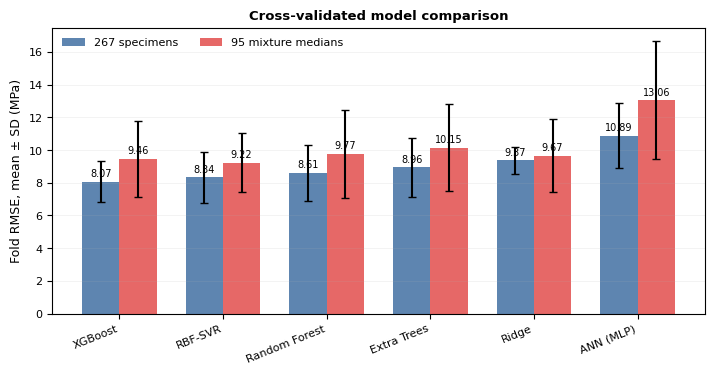

In [17]:
specimen_plot = (
    specimen_performance
    .sort_values("Fold_RMSE_mean_MPa")
    .reset_index(drop=True)
)
model_order = specimen_plot["Model"].tolist()

gui_plot = (
    gui_performance
    .set_index("Model")
    .loc[model_order]
    .reset_index()
)

print("267 specimens")
display(specimen_plot[[
    "Model",
    "Fold_RMSE_mean_MPa",
    "Fold_RMSE_SD_MPa",
    "Pooled_R2",
    "Pooled_MAE_MPa",
    "Pooled_RMSE_MPa",
]])

print("95 mixture medians")
display(gui_plot[[
    "Model",
    "Fold_RMSE_mean_MPa",
    "Fold_RMSE_SD_MPa",
    "Pooled_R2",
    "Pooled_MAE_MPa",
    "Pooled_RMSE_MPa",
]])

x = np.arange(len(model_order))
width = 0.36

fig, ax = plt.subplots(figsize=(7.2, 3.8))

bars_specimen = ax.bar(
    x - width / 2,
    specimen_plot["Fold_RMSE_mean_MPa"],
    width,
    yerr=specimen_plot["Fold_RMSE_SD_MPa"],
    capsize=3,
    label="267 specimens",
    color="#4C78A8",
    alpha=0.9,
)
bars_gui = ax.bar(
    x + width / 2,
    gui_plot["Fold_RMSE_mean_MPa"],
    width,
    yerr=gui_plot["Fold_RMSE_SD_MPa"],
    capsize=3,
    label="95 mixture medians",
    color="#E45756",
    alpha=0.9,
)

for bars, values in [
    (bars_specimen, specimen_plot["Fold_RMSE_mean_MPa"]),
    (bars_gui, gui_plot["Fold_RMSE_mean_MPa"]),
]:
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.18,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=22, ha="right")
ax.set_ylabel("Fold RMSE, mean ± SD (MPa)")
ax.set_title("Cross-validated model comparison", fontweight="bold")
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.grid(axis="y", alpha=0.2, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Figure_3_model_comparison")


## 13. Figures 4 and 5 — parity plots

The plots use identical axes, marker size, transparency, and an ±RMSE band.



 Grouped XGBoost predictions: 267 specimens
Model               XGBoost
Pooled_R2           0.95292
Pooled_MAE_MPa     6.582922
Pooled_RMSE_MPa    8.153054


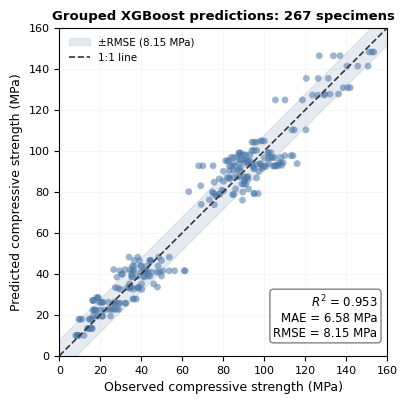


 Random Forest screening model: 95 mixtures
Model              Random Forest
Pooled_R2               0.904472
Pooled_MAE_MPa          7.699998
Pooled_RMSE_MPa          10.0647


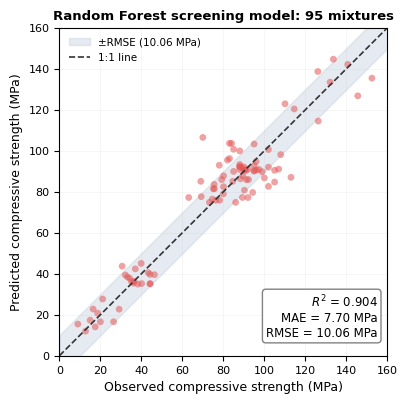

In [18]:
def create_parity_plot(data, metric_row, title, color, stem):
    print("\n", title)
    print(metric_row[[
        "Model",
        "Pooled_R2",
        "Pooled_MAE_MPa",
        "Pooled_RMSE_MPa",
    ]].to_string())

    axis_min = 0
    axis_max = 160
    line_values = np.linspace(axis_min, axis_max, 400)
    rmse = float(metric_row["Pooled_RMSE_MPa"])

    fig, ax = plt.subplots(figsize=(4.2, 4.1))
    ax.fill_between(
        line_values,
        line_values - rmse,
        line_values + rmse,
        color="#B9C7D8",
        alpha=0.35,
        label=f"±RMSE ({rmse:.2f} MPa)",
    )
    ax.plot(
        line_values,
        line_values,
        linestyle="--",
        color="#333333",
        linewidth=1.2,
        label="1:1 line",
    )
    ax.scatter(
        data["Observed_CS_MPa"],
        data["Predicted_CS_MPa"],
        s=24,
        alpha=0.55,
        color=color,
        edgecolor="none",
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Observed compressive strength (MPa)")
    ax.set_ylabel("Predicted compressive strength (MPa)")
    ax.set_title(title, fontweight="bold")

    annotation = (
        f"$R^2$ = {metric_row['Pooled_R2']:.3f}\n"
        f"MAE = {metric_row['Pooled_MAE_MPa']:.2f} MPa\n"
        f"RMSE = {metric_row['Pooled_RMSE_MPa']:.2f} MPa"
    )
    ax.text(
        0.97,
        0.05,
        annotation,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#777777",
            "alpha": 0.92,
        },
    )
    ax.legend(frameon=False, loc="upper left", fontsize=7.5)
    ax.grid(alpha=0.15, linewidth=0.5)
    fig.tight_layout()
    save_figure(fig, stem)


create_parity_plot(
    specimen_oof,
    xgb_row,
    "Grouped XGBoost predictions: 267 specimens",
    "#4C78A8",
    "Figure_4_specimen_parity",
)

create_parity_plot(
    gui_oof,
    rf_gui_row,
    "Random Forest screening model: 95 mixtures",
    "#E45756",
    "Figure_5_gui_parity",
)


## 14. Figure 6 — residual diagnostics


{'residual_mean': -0.11120677619503314, 'residual_sd': 10.117476072443718, 'plus_minus_1.96_sd': 19.830253101989687, 'minimum_residual': -36.52246924603183, 'maximum_residual': 25.92907559523806}


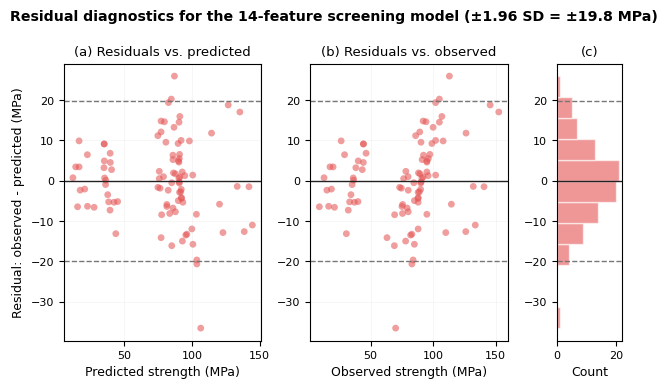

In [19]:
residual_sd = float(gui_oof["Residual_MPa"].std(ddof=1))
reference_limit = 1.96 * residual_sd

print({
    "residual_mean": float(gui_oof["Residual_MPa"].mean()),
    "residual_sd": residual_sd,
    "plus_minus_1.96_sd": reference_limit,
    "minimum_residual": float(gui_oof["Residual_MPa"].min()),
    "maximum_residual": float(gui_oof["Residual_MPa"].max()),
})

fig = plt.figure(figsize=(7.2, 3.6))
grid = fig.add_gridspec(
    1,
    3,
    width_ratios=[1, 1, 0.33],
    wspace=0.32,
)

ax_predicted = fig.add_subplot(grid[0, 0])
ax_observed = fig.add_subplot(grid[0, 1], sharey=ax_predicted)
ax_histogram = fig.add_subplot(grid[0, 2], sharey=ax_predicted)

for ax, x_variable, x_label in [
    (
        ax_predicted,
        "Predicted_CS_MPa",
        "Predicted strength (MPa)",
    ),
    (
        ax_observed,
        "Observed_CS_MPa",
        "Observed strength (MPa)",
    ),
]:
    ax.scatter(
        gui_oof[x_variable],
        gui_oof["Residual_MPa"],
        s=24,
        alpha=0.58,
        color="#E45756",
        edgecolor="none",
    )
    ax.axhline(0, color="#222222", linewidth=1.0)
    ax.axhline(
        reference_limit,
        color="#777777",
        linestyle="--",
        linewidth=1.0,
    )
    ax.axhline(
        -reference_limit,
        color="#777777",
        linestyle="--",
        linewidth=1.0,
    )
    ax.set_xlabel(x_label)
    ax.grid(alpha=0.15, linewidth=0.5)

ax_predicted.set_ylabel(
    "Residual: observed - predicted (MPa)"
)
ax_predicted.set_title("(a) Residuals vs. predicted")
ax_observed.set_title("(b) Residuals vs. observed")

ax_histogram.hist(
    gui_oof["Residual_MPa"],
    bins=12,
    orientation="horizontal",
    color="#E45756",
    alpha=0.62,
    edgecolor="white",
)
ax_histogram.axhline(0, color="#222222", linewidth=1.0)
ax_histogram.axhline(
    reference_limit,
    color="#777777",
    linestyle="--",
    linewidth=1.0,
)
ax_histogram.axhline(
    -reference_limit,
    color="#777777",
    linestyle="--",
    linewidth=1.0,
)
ax_histogram.set_xlabel("Count")
ax_histogram.set_title("(c)")

fig.suptitle(
    (
        "Residual diagnostics for the 14-feature screening model "
        f"(±1.96 SD = ±{reference_limit:.1f} MPa)"
    ),
    y=1.03,
    fontweight="bold",
)
fig.tight_layout()
save_figure(fig, "Figure_6_residual_diagnostics")


## 15. Fit the final screening model and generate SHAP values


In [20]:
final_gui_model = clone(gui_models["Random Forest"])
final_gui_model.fit(X_gui, y_gui)

gui_bundle = {
    "model": final_gui_model,
    "features": GUI_FEATURES,
    "feature_min": X_gui.min().to_dict(),
    "feature_max": X_gui.max().to_dict(),
    "target_definition": (
        "Median compressive strength for a unique mixture."
    ),
    "excluded_user_inputs": [
        "Loading_Direction_code",
        "Fiber_Type_code",
    ],
    "prediction_intervals_reported": False,
    "engineering_disclaimer": (
        "Screening estimate only. Laboratory printing, mechanical "
        "testing, durability assessment, and engineering verification "
        "remain necessary."
    ),
}

model_path = MODEL_DIR / "revised_gui_random_forest_14_features.joblib"
joblib.dump(gui_bundle, model_path)

transformed_gui = np.asarray(
    final_gui_model
    .named_steps["preprocess"]
    .transform(X_gui),
    dtype=float,
)
fitted_forest = final_gui_model.named_steps["model"]

tree_explainer = shap.TreeExplainer(fitted_forest)
gui_shap_values = np.asarray(
    tree_explainer.shap_values(transformed_gui)
)

shap_importance = pd.DataFrame({
    "Feature": GUI_FEATURES,
    "Mean_abs_SHAP_MPa": np.mean(
        np.abs(gui_shap_values),
        axis=0,
    ),
}).sort_values(
    "Mean_abs_SHAP_MPa",
    ascending=False,
)

shap_importance.to_csv(
    TABLE_DIR / "gui_shap_importance_14_features.csv",
    index=False,
)
pd.DataFrame(
    gui_shap_values,
    columns=GUI_FEATURES,
).to_csv(
    TABLE_DIR / "gui_shap_values_14_features.csv",
    index=False,
)

print("Saved final screening model:", model_path)
display(shap_importance)


Saved final screening model: /content/3dpc_trb_analysis/results/models/revised_gui_random_forest_14_features.joblib


,Feature,Mean_abs_SHAP_MPa
2,Water_Binder_Ratio,9.500085
8,Water_kg_m3,9.155017
5,Silica_Fume_kg_m3,6.474757
12,Fiber_Diameter_source_um,1.997458
9,Fiber_Volume_source_scale,1.926796
6,Superplasticizer_kg_m3,1.797595
0,OPC_kg_m3,0.974391
11,Fiber_Aspect_Ratio,0.871224
4,GGBS_or_GS_kg_m3,0.828794
1,Sand_kg_m3,0.736270


## 16. Figure 7 — SHAP beeswarm

Feature values are standardized because SHAP is calculated on the preprocessed feature matrix.


Numeric values used in Figure 7


,Feature,Mean_abs_SHAP_MPa
2,Water_Binder_Ratio,9.500085
8,Water_kg_m3,9.155017
5,Silica_Fume_kg_m3,6.474757
12,Fiber_Diameter_source_um,1.997458
9,Fiber_Volume_source_scale,1.926796
6,Superplasticizer_kg_m3,1.797595
0,OPC_kg_m3,0.974391
11,Fiber_Aspect_Ratio,0.871224
4,GGBS_or_GS_kg_m3,0.828794
1,Sand_kg_m3,0.736270


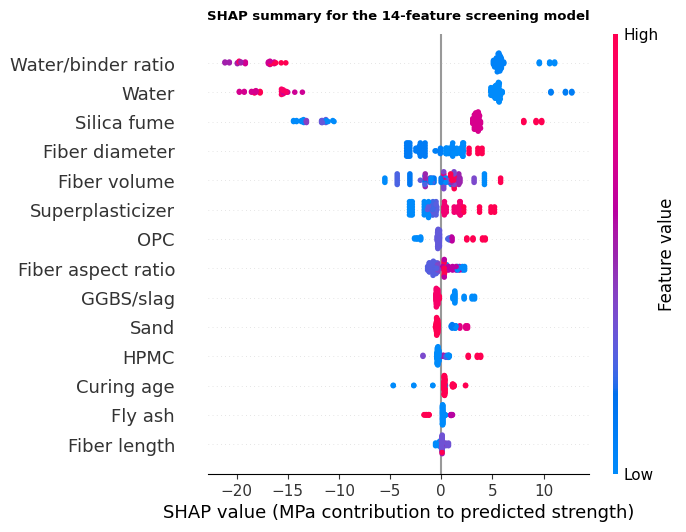

In [21]:
friendly_feature_names = {
    "OPC_kg_m3": "OPC",
    "Sand_kg_m3": "Sand",
    "Water_Binder_Ratio": "Water/binder ratio",
    "Fly_Ash_kg_m3": "Fly ash",
    "GGBS_or_GS_kg_m3": "GGBS/slag",
    "Silica_Fume_kg_m3": "Silica fume",
    "Superplasticizer_kg_m3": "Superplasticizer",
    "HPMC_kg_m3": "HPMC",
    "Water_kg_m3": "Water",
    "Fiber_Volume_source_scale": "Fiber volume",
    "Curing_Age_days": "Curing age",
    "Fiber_Aspect_Ratio": "Fiber aspect ratio",
    "Fiber_Diameter_source_um": "Fiber diameter",
    "Fiber_Length_mm": "Fiber length",
}

print("Numeric values used in Figure 7")
display(shap_importance)

plt.figure(figsize=(7.0, 5.2))
shap.summary_plot(
    gui_shap_values,
    transformed_gui,
    feature_names=[
        friendly_feature_names[feature]
        for feature in GUI_FEATURES
    ],
    max_display=14,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_xlabel(
    "SHAP value (MPa contribution to predicted strength)"
)
ax.set_title(
    "SHAP summary for the 14-feature screening model",
    fontweight="bold",
    pad=10,
)
fig = plt.gcf()
save_figure(fig, "Figure_7_shap_beeswarm")


## 17. Optional supplementary SHAP importance bar chart


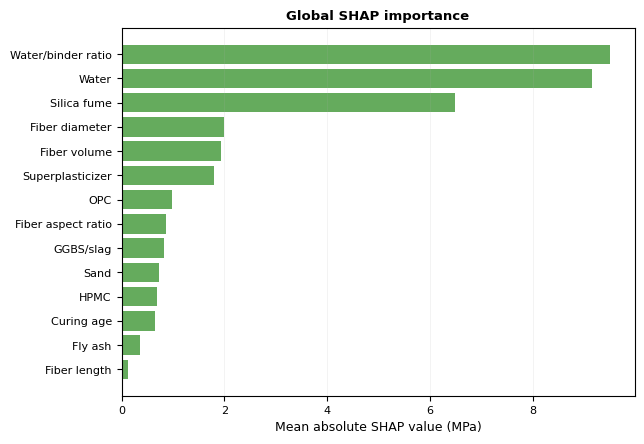

In [22]:
plot_importance = shap_importance.copy()
plot_importance["Label"] = plot_importance["Feature"].map(
    friendly_feature_names
)
plot_importance = plot_importance.sort_values(
    "Mean_abs_SHAP_MPa",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(
    plot_importance["Label"],
    plot_importance["Mean_abs_SHAP_MPa"],
    color="#54A24B",
    alpha=0.9,
)
ax.set_xlabel("Mean absolute SHAP value (MPa)")
ax.set_title("Global SHAP importance", fontweight="bold")
ax.grid(axis="x", alpha=0.2, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Figure_S1_shap_bar")


## 18. Launch the simplified Gradio screening interface

This interface:

- uses 14 continuous inputs;
- excludes loading direction and fiber type;
- reports no 90% or 95% prediction intervals;
- provides a training-range warning and local SHAP explanation.

Run this cell only after the final model has been fitted.


In [23]:
import gradio as gr

GUI_LABELS = {
    "OPC_kg_m3": "OPC (kg/m³)",
    "Sand_kg_m3": "Sand (kg/m³)",
    "Water_Binder_Ratio": "Water-to-binder ratio",
    "Fly_Ash_kg_m3": "Fly ash (kg/m³)",
    "GGBS_or_GS_kg_m3": "GGBS/slag (kg/m³)",
    "Silica_Fume_kg_m3": "Silica fume (kg/m³)",
    "Superplasticizer_kg_m3": "Superplasticizer (kg/m³)",
    "HPMC_kg_m3": "HPMC (kg/m³)",
    "Water_kg_m3": "Water (kg/m³)",
    "Fiber_Volume_source_scale": (
        "Fiber volume (source scale)"
    ),
    "Curing_Age_days": "Curing age (days)",
    "Fiber_Aspect_Ratio": "Fiber aspect ratio",
    "Fiber_Diameter_source_um": (
        "Fiber diameter (source scale)"
    ),
    "Fiber_Length_mm": "Fiber length (mm)",
}

GUI_DEFAULTS = {
    feature: float(mixture_data[feature].median())
    for feature in GUI_FEATURES
}

def input_domain_message(row):
    outside = []
    for feature in GUI_FEATURES:
        value = float(row.iloc[0][feature])
        minimum = float(gui_bundle["feature_min"][feature])
        maximum = float(gui_bundle["feature_max"][feature])

        if value < minimum or value > maximum:
            outside.append(
                f"{GUI_LABELS[feature]}={value:g}; "
                f"training range {minimum:g}-{maximum:g}"
            )

    if outside:
        return "Outside training range: " + "; ".join(outside)
    return "Within individual training ranges."


def local_shap_plot(row):
    transformed = np.asarray(
        final_gui_model
        .named_steps["preprocess"]
        .transform(row),
        dtype=float,
    )
    values = np.asarray(
        shap.TreeExplainer(fitted_forest).shap_values(transformed)
    )[0]

    ranking = pd.DataFrame({
        "Feature": GUI_FEATURES,
        "SHAP": values,
    })
    ranking["Absolute"] = ranking["SHAP"].abs()
    ranking = (
        ranking
        .nlargest(8, "Absolute")
        .sort_values("SHAP")
    )

    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.barh(
        [
            GUI_LABELS[feature]
            for feature in ranking["Feature"]
        ],
        ranking["SHAP"],
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Local SHAP contribution (MPa)")
    ax.set_title("Largest contributions to this prediction")
    fig.tight_layout()
    return fig


def predict_strength(*values):
    row = pd.DataFrame(
        [dict(zip(GUI_FEATURES, values))],
        columns=GUI_FEATURES,
    )
    prediction = float(final_gui_model.predict(row)[0])

    message = (
        f"## Predicted median compressive strength: "
        f"**{prediction:.2f} MPa**\n\n"
        f"**Input-domain check:** {input_domain_message(row)}\n\n"
        "**Engineering-use disclaimer:** This is a "
        "literature-derived screening estimate. Laboratory printing, "
        "mechanical testing, durability assessment, and engineering "
        "verification remain necessary."
    )
    return message, local_shap_plot(row)


with gr.Blocks(
    title="3D-Printed Concrete Strength Screening"
) as app:
    gr.Markdown(
        "# 3D-Printed Concrete Compressive-Strength Screening Tool"
    )

    gui_inputs = []
    for start in range(0, len(GUI_FEATURES), 3):
        with gr.Row():
            for feature in GUI_FEATURES[start:start + 3]:
                gui_inputs.append(
                    gr.Number(
                        label=GUI_LABELS[feature],
                        value=GUI_DEFAULTS[feature],
                    )
                )

    predict_button = gr.Button(
        "Predict compressive strength",
        variant="primary",
    )
    prediction_output = gr.Markdown()
    explanation_output = gr.Plot()

    predict_button.click(
        predict_strength,
        inputs=gui_inputs,
        outputs=[
            prediction_output,
            explanation_output,
        ],
    )

# In Colab, share=True creates a temporary public link.
app.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e05f7342c908bdcdce.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 19. Save a machine-readable results summary and download all outputs


In [24]:
results_summary = {
    "specimen_model": {
        "selected_model": "XGBoost",
        "records": int(len(specimen_data)),
        "independent_mixtures": int(
            specimen_data["Full_Input_Group_ID"].nunique()
        ),
        "predictors": len(SPECIMEN_FEATURES),
        "R2": float(xgb_row["Pooled_R2"]),
        "MAE_MPa": float(xgb_row["Pooled_MAE_MPa"]),
        "RMSE_MPa": float(xgb_row["Pooled_RMSE_MPa"]),
    },
    "screening_model": {
        "selected_model": "Random Forest",
        "records": int(len(mixture_data)),
        "predictors": len(GUI_FEATURES),
        "excluded_inputs": CATEGORICAL_FEATURES,
        "prediction_intervals_reported": False,
        "R2": float(rf_gui_row["Pooled_R2"]),
        "MAE_MPa": float(rf_gui_row["Pooled_MAE_MPa"]),
        "RMSE_MPa": float(rf_gui_row["Pooled_RMSE_MPa"]),
    },
    "normalized_cs_transferability": {
        "random_best": {
            "model": str(random_best["Model"]),
            "R2": float(random_best["Pooled_R2"]),
            "MAE_MPa": float(random_best["Pooled_MAE_MPa"]),
            "RMSE_MPa": float(random_best["Pooled_RMSE_MPa"]),
        },
        "source_grouped_best": {
            "model": str(grouped_best["Model"]),
            "R2": float(grouped_best["Pooled_R2"]),
            "MAE_MPa": float(grouped_best["Pooled_MAE_MPa"]),
            "RMSE_MPa": float(grouped_best["Pooled_RMSE_MPa"]),
        },
    },
}

summary_path = RESULTS_DIR / "final_results.json"
summary_path.write_text(
    json.dumps(results_summary, indent=2),
    encoding="utf-8",
)

archive_base = Path("/content/TRB_3DPC_Colab_Results")
archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=RESULTS_DIR,
)

print(json.dumps(results_summary, indent=2))
print("\nCreated archive:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Download manually from:", archive_path)


{
  "specimen_model": {
    "selected_model": "XGBoost",
    "records": 267,
    "independent_mixtures": 95,
    "predictors": 16,
    "R2": 0.9529201675748235,
    "MAE_MPa": 6.58292200536248,
    "RMSE_MPa": 8.153054129304582
  },
  "screening_model": {
    "selected_model": "Random Forest",
    "records": 95,
    "predictors": 14,
    "excluded_inputs": [
      "Loading_Direction_code",
      "Fiber_Type_code"
    ],
    "prediction_intervals_reported": false,
    "R2": 0.904471519698111,
    "MAE_MPa": 7.699998219458304,
    "RMSE_MPa": 10.064699715843801
  },
  "normalized_cs_transferability": {
    "random_best": {
      "model": "Extra Trees",
      "R2": 0.8987994853902299,
      "MAE_MPa": 5.805435742907901,
      "RMSE_MPa": 10.02033414124483
    },
    "source_grouped_best": {
      "model": "XGBoost",
      "R2": 0.0015767090809061246,
      "MAE_MPa": 25.507386976377234,
      "RMSE_MPa": 31.473728575271288
    }
  }
}

Created archive: /content/TRB_3DPC_Colab_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>